<a href="https://colab.research.google.com/github/sved07/XGB-Cascade-Classifier/blob/main/idk_cascade_xgb_vs_rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cost-Sensitive IDK Cascade Router: XGBoost vs. Random Forest Comparison

This notebook compares an **XGBoost meta-router** against a **Random Forest meta-router** under identical pipeline conditions:
1. **Same Telemetry Features**: `confidence`, `entropy`, and `margin` from Front-End Model A.
2. **Same Asymmetric Loss / Cost Weighting**: Class 1 weights are scaled identically (`scale_pos_weight` in XGBoost vs `class_weight` in Random Forest).
3. **Single-Sample Latency Profiling**: Real per-row measurements (batch size 1).
4. **Multi-Seed Replication & Paired Significance Tests**: Direct comparison across seeds.
5. **Micro-Overhead Benchmarking**: Per-sample prediction latency comparison between tree models.


In [34]:
!pip install -q xgboost scikit-learn pandas numpy torch torchvision scipy matplotlib


In [35]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using execution device: {device}")


Using execution device: cuda


## 1. Dataset and Models Setup

In [36]:
DATASETS = {
    'CIFAR-100': {
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
        ]),
        'num_classes': 100
    },
    'CIFAR-10': {
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616])
        ]),
        'num_classes': 10
    }
}

def get_dataset(dataset_name, transform):
    if dataset_name == 'CIFAR-100':
        return torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
    elif dataset_name == 'CIFAR-10':
        return torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

def load_models_for_dataset(dataset_name):
    if dataset_name == 'CIFAR-100':
        model_a = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet20", pretrained=True).to(device)
        model_b = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet32", pretrained=True).to(device)
        model_c = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet56", pretrained=True).to(device)
    elif dataset_name == 'CIFAR-10':
        model_a = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True).to(device)
        model_b = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet32", pretrained=True).to(device)
        model_c = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet56", pretrained=True).to(device)
    model_a.eval()
    model_b.eval()
    model_c.eval()
    return model_a, model_b, model_c

transform = DATASETS['CIFAR-100']['transform']
val_dataset = get_dataset('CIFAR-100', transform)
model_a, model_b, model_c = load_models_for_dataset('CIFAR-100')
print("Base models and CIFAR-100 dataset loaded successfully.")


Base models and CIFAR-100 dataset loaded successfully.


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


## 2. Single-Sample Latency Profiling

In [37]:
def measure_single_sample_latency(model, single_sample, n_reps=300, n_warmup=30, device=device):
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(single_sample)
        if device.type == "cuda":
            torch.cuda.synchronize()

        for _ in range(n_reps):
            start = time.perf_counter()
            _ = model(single_sample)
            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append((end - start) * 1000)

    times = np.array(times)
    return times.mean(), times.std()

probe_batch = val_dataset[0][0].unsqueeze(0).to(device)
LATENCY_A, LATENCY_A_STD = measure_single_sample_latency(model_a, probe_batch)
LATENCY_B, LATENCY_B_STD = measure_single_sample_latency(model_b, probe_batch)
LATENCY_C, LATENCY_C_STD = measure_single_sample_latency(model_c, probe_batch)

print(f"Model A Single-Sample Latency: {LATENCY_A:.4f} +/- {LATENCY_A_STD:.4f} ms")
print(f"Model C Single-Sample Latency: {LATENCY_C:.4f} +/- {LATENCY_C_STD:.4f} ms")


Model A Single-Sample Latency: 2.6975 +/- 0.2037 ms
Model C Single-Sample Latency: 6.8310 +/- 0.3054 ms


## 3. Router Training Logic: XGBoost vs. Random Forest

Both routers are given the exact same features (`confidence`, `entropy`, `margin`) and class penalty factor derived from the cost of escalation.

In [38]:
EARLY_EXIT_THRESHOLD = 0.90

def extract_telemetry(loader, model_a, model_c, device=device):
    rows = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs_a = model_a(images)
            probs_a = torch.softmax(outputs_a, dim=1)
            conf_A, preds_a = torch.max(probs_a, dim=1)
            entropy_A = -torch.sum(probs_a * torch.log(probs_a + 1e-6), dim=1)
            top2, _ = torch.topk(probs_a, k=2, dim=1)
            margin_A = top2[:, 0] - top2[:, 1]

            outputs_c = model_c(images)
            _, preds_c = torch.max(outputs_c, dim=1)

            actual_route_to_c = ((preds_a != labels) & (preds_c == labels)).long()

            for i in range(images.size(0)):
                rows.append({
                    'confidence': conf_A[i].item(),
                    'entropy': entropy_A[i].item(),
                    'margin': margin_A[i].item(),
                    'correct_a': (preds_a[i] == labels[i]).item(),
                    'correct_c': (preds_c[i] == labels[i]).item(),
                    'target_route': actual_route_to_c[i].item(),
                })
    return pd.DataFrame(rows)

def train_xgb_router(X_train, y_train, latency_c, cost_missed_fallback=1.0, seed=42):
    asymmetric_multiplier = cost_missed_fallback / max(latency_c, 1e-6)
    num_pos = np.sum(y_train == 1)
    num_neg = np.sum(y_train == 0)
    base_weight = num_neg / max(num_pos, 1)
    tuned_scale_pos_weight = base_weight * asymmetric_multiplier

    router = xgb.XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1,
        scale_pos_weight=tuned_scale_pos_weight, eval_metric='logloss', random_state=seed
    )
    router.fit(X_train, y_train)
    return router

def train_rf_router(X_train, y_train, latency_c, cost_missed_fallback=1.0, seed=42):
    asymmetric_multiplier = cost_missed_fallback / max(latency_c, 1e-6)
    num_pos = np.sum(y_train == 1)
    num_neg = np.sum(y_train == 0)
    base_weight = num_neg / max(num_pos, 1)
    pos_weight = base_weight * asymmetric_multiplier

    router = RandomForestClassifier(
        n_estimators=50, max_depth=3,
        class_weight={0: 1.0, 1: pos_weight},
        random_state=seed
    )
    router.fit(X_train, y_train)
    return router


## 7. Single-Sample Router Inference Micro-Overhead Timing

Measures the per-row prediction latency added purely by the meta-routers.

In [39]:
def measure_router_overhead_per_sample(router, X_test, n_reps=5):
    X_arr = X_test.values if hasattr(X_test, 'values') else X_test
    times = []
    for _ in range(n_reps):
        for row in X_arr:
            row = row.reshape(1, -1)
            start = time.perf_counter()
            _ = router.predict_proba(row)
            end = time.perf_counter()
            times.append((end - start) * 1000)
    times = np.array(times)
    return times.mean(), times.std()

# Train sample routers for overhead measurement
torch.manual_seed(42)
subset = torch.utils.data.Subset(val_dataset, list(range(1000)))
loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)
df_probe = extract_telemetry(loader, model_a, model_c)
X_probe = df_probe[['confidence', 'entropy', 'margin']]
y_probe = df_probe['target_route']
X_tr, X_te, y_tr, y_te = train_test_split(X_probe, y_probe, test_size=0.2, random_state=42)

xgb_bench = train_xgb_router(X_tr, y_tr, LATENCY_C, seed=42)
rf_bench = train_rf_router(X_tr, y_tr, LATENCY_C, seed=42)

xgb_overhead_mean, xgb_overhead_std = measure_router_overhead_per_sample(xgb_bench, X_te.head(200))
rf_overhead_mean, rf_overhead_std = measure_router_overhead_per_sample(rf_bench, X_te.head(200))

print(f"[METRIC] XGBoost Router Overhead  : {xgb_overhead_mean:.5f} +/- {xgb_overhead_std:.5f} ms/sample")
print(f"[METRIC] Random Forest Overhead  : {rf_overhead_mean:.5f} +/- {rf_overhead_std:.5f} ms/sample")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

[METRIC] XGBoost Router Overhead  : 0.46472 +/- 0.05930 ms/sample
[METRIC] Random Forest Overhead  : 3.25835 +/- 0.22693 ms/sample


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

## 4. Evaluation and Naive Baseline

In [40]:
def naive_threshold_cascade(raw_df, tau, LATENCY_A, LATENCY_C):
    route = (raw_df['confidence'] < tau).astype(int)
    latency = LATENCY_A + route * LATENCY_C
    correct = np.where(route == 1, raw_df['correct_c'], raw_df['correct_a'])
    return {
        'avg_latency': latency.mean(),
        'accuracy': correct.mean() * 100,
    }

def evaluate_router_cascade(router, X_test, raw_test, LATENCY_A, LATENCY_C, theta=0.20):
    n = len(raw_test)
    router_probs = router.predict_proba(X_test)[:, 1]
    decisions = np.where(router_probs >= theta, 1, 0)

    # NEW: measure this router's own per-sample overhead once, up front
    router_overhead_mean, _ = measure_router_overhead_per_sample(router, X_test.head(200))

    latency_total = 0.0
    correct = 0
    for i in range(n):
        latency_total += LATENCY_A + router_overhead_mean   # <- overhead now counted
        if raw_test.loc[i, 'confidence'] >= EARLY_EXIT_THRESHOLD:
            correct += raw_test.loc[i, 'correct_a']
        elif decisions[i] == 1:
            latency_total += LATENCY_C
            correct += raw_test.loc[i, 'correct_c']
        else:
            correct += raw_test.loc[i, 'correct_a']

    return {'avg_latency': latency_total / n, 'accuracy': (correct / n) * 100}


## 5. Multi-Seed Replication: XGBoost vs. Random Forest

Runs both router models across identical seeds and data splits to capture mean and standard deviation for accuracy and latency.

In [41]:
def run_seed_trial_comparison(seed, n_samples, chosen_theta, dataset_name, models, transform, latency_a, latency_c):
    torch.manual_seed(seed)
    val_dataset_current = get_dataset(dataset_name, transform)
    idx = torch.randperm(len(val_dataset_current))[:n_samples]
    subset = torch.utils.data.Subset(val_dataset_current, idx)
    loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)

    model_a, _, model_c = models
    df = extract_telemetry(loader, model_a, model_c)
    X = df[['confidence', 'entropy', 'margin']]
    y = df['target_route']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    raw_test = df.loc[X_test.index].reset_index(drop=True)
    X_test_reset = X_test.reset_index(drop=True)

    # Train both routers
    xgb_router = train_xgb_router(X_train, y_train, latency_c, seed=seed)
    rf_router = train_rf_router(X_train, y_train, latency_c, seed=seed)

    xgb_res = evaluate_router_cascade(xgb_router, X_test_reset, raw_test, latency_a, latency_c, theta=chosen_theta)
    rf_res = evaluate_router_cascade(rf_router, X_test_reset, raw_test, latency_a, latency_c, theta=chosen_theta)

    acc_expert = raw_test['correct_c'].mean() * 100
    naive_res = naive_threshold_cascade(raw_test, tau=0.80, LATENCY_A=latency_a, LATENCY_C=latency_c)

    return {
        'dataset': dataset_name,
        'seed': seed,
        'xgb_accuracy': xgb_res['accuracy'],
        'xgb_latency': xgb_res['avg_latency'],
        'rf_accuracy': rf_res['accuracy'],
        'rf_latency': rf_res['avg_latency'],
        'expert_accuracy': acc_expert,
        'expert_latency': latency_c,
        'naive_accuracy': naive_res['accuracy'],
        'naive_latency': naive_res['avg_latency'],
    }

SEEDS = [1, 2, 3, 4, 5, 6, 7, 8]
CHOSEN_THETA = 0.20
N_SAMPLES_PER_SEED = 4000
DATASETS_TO_EVALUATE = ['CIFAR-100', 'CIFAR-10']

all_trial_results = []
for dataset_name in DATASETS_TO_EVALUATE:
    print(f"\n=== Running multi-router trial for dataset: {dataset_name} ===")
    current_transform = DATASETS[dataset_name]['transform']
    current_models = load_models_for_dataset(dataset_name)

    dataset_trial_results = [
        run_seed_trial_comparison(s, N_SAMPLES_PER_SEED, CHOSEN_THETA, dataset_name, current_models, current_transform, LATENCY_A, LATENCY_C)
        for s in SEEDS
    ]
    all_trial_results.extend(dataset_trial_results)

trial_df = pd.DataFrame(all_trial_results)
print("\nAll multi-seed trials completed successfully.")
print(trial_df.head())



=== Running multi-router trial for dataset: CIFAR-100 ===


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fi


=== Running multi-router trial for dataset: CIFAR-10 ===


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fi


All multi-seed trials completed successfully.
     dataset  seed  xgb_accuracy  xgb_latency  rf_accuracy  rf_latency  \
0  CIFAR-100     1        73.125     5.226427       73.875    8.240633   
1  CIFAR-100     2        72.125     5.406298       72.500    8.549962   
2  CIFAR-100     3        72.875     5.093486       73.250    8.241062   
3  CIFAR-100     4        73.875     5.423473       74.125    8.351777   
4  CIFAR-100     5        74.000     5.539040       74.125    8.492709   

   expert_accuracy  expert_latency  naive_accuracy  naive_latency  
0           73.750        6.830966          74.625       5.301765  
1           73.500        6.830966          72.500       5.404230  
2           71.500        6.830966          72.875       5.455462  
3           74.375        6.830966          74.000       5.421307  
4           72.625        6.830966          74.125       5.446923  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [42]:
print("=== Summary Performance Across All Seeds & Datasets ===")
print(f"XGBoost Router Accuracy   : {trial_df['xgb_accuracy'].mean():.2f} +/- {trial_df['xgb_accuracy'].std():.2f} %")
print(f"Random Forest Accuracy  : {trial_df['rf_accuracy'].mean():.2f} +/- {trial_df['rf_accuracy'].std():.2f} %")
print(f"Pure Expert Accuracy     : {trial_df['expert_accuracy'].mean():.2f} +/- {trial_df['expert_accuracy'].std():.2f} %")
print(f"Naive Baseline Accuracy  : {trial_df['naive_accuracy'].mean():.2f} +/- {trial_df['naive_accuracy'].std():.2f} %")
print()
print(f"XGBoost Cascade Latency  : {trial_df['xgb_latency'].mean():.4f} +/- {trial_df['xgb_latency'].std():.4f} ms")
print(f"Random Forest Latency   : {trial_df['rf_latency'].mean():.4f} +/- {trial_df['rf_latency'].std():.4f} ms")
print(f"Pure Expert Latency      : {trial_df['expert_latency'].mean():.4f} ms")


=== Summary Performance Across All Seeds & Datasets ===
XGBoost Router Accuracy   : 83.48 +/- 10.76 %
Random Forest Accuracy  : 83.59 +/- 10.65 %
Pure Expert Accuracy     : 83.44 +/- 11.14 %
Naive Baseline Accuracy  : 83.45 +/- 10.53 %

XGBoost Cascade Latency  : 4.6353 +/- 0.7691 ms
Random Forest Latency   : 7.5628 +/- 0.8658 ms
Pure Expert Latency      : 6.8310 ms


## 6. Paired Statistical Significance Testing

Tests whether XGBoost's performance differs significantly from Random Forest.

In [43]:
def paired_report(a, b, label_a, label_b):
    diffs = np.array(a) - np.array(b)
    t_stat, p_val = stats.ttest_rel(a, b)
    try:
        w_stat, w_p = stats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    print(f"  Mean Diff ({label_a} - {label_b}): {diffs.mean():+.3f} pp, Std: {diffs.std():.3f} pp")
    print(f"  Paired t-test        : t = {t_stat:.3f}, p = {p_val:.4f}")
    print(f"  Wilcoxon signed-rank : p = {w_p:.4f}")
    print()

for dataset_name in trial_df['dataset'].unique():
    print(f"--- Paired Tests for {dataset_name} ---")
    ds_df = trial_df[trial_df['dataset'] == dataset_name]

    print("XGBoost Router vs. Random Forest Router (Accuracy):")
    paired_report(ds_df['xgb_accuracy'], ds_df['rf_accuracy'], 'XGBoost', 'Random Forest')

    print("XGBoost Router vs. Random Forest Router (Latency):")
    paired_report(ds_df['xgb_latency'], ds_df['rf_latency'], 'XGBoost Latency', 'RF Latency')


--- Paired Tests for CIFAR-100 ---
XGBoost Router vs. Random Forest Router (Accuracy):
  Mean Diff (XGBoost - Random Forest): -0.203 pp, Std: 0.286 pp
  Paired t-test        : t = -1.879, p = 0.1023
  Wilcoxon signed-rank : p = 0.1250

XGBoost Router vs. Random Forest Router (Latency):
  Mean Diff (XGBoost Latency - RF Latency): -3.020 pp, Std: 0.100 pp
  Paired t-test        : t = -79.592, p = 0.0000
  Wilcoxon signed-rank : p = 0.0078

--- Paired Tests for CIFAR-10 ---
XGBoost Router vs. Random Forest Router (Accuracy):
  Mean Diff (XGBoost - Random Forest): +0.000 pp, Std: 0.000 pp
  Paired t-test        : t = nan, p = nan
  Wilcoxon signed-rank : p = 1.0000

XGBoost Router vs. Random Forest Router (Latency):
  Mean Diff (XGBoost Latency - RF Latency): -2.835 pp, Std: 0.079 pp
  Paired t-test        : t = -94.424, p = 0.0000
  Wilcoxon signed-rank : p = 0.0078



/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


## 8. Visualizing Pareto Frontiers

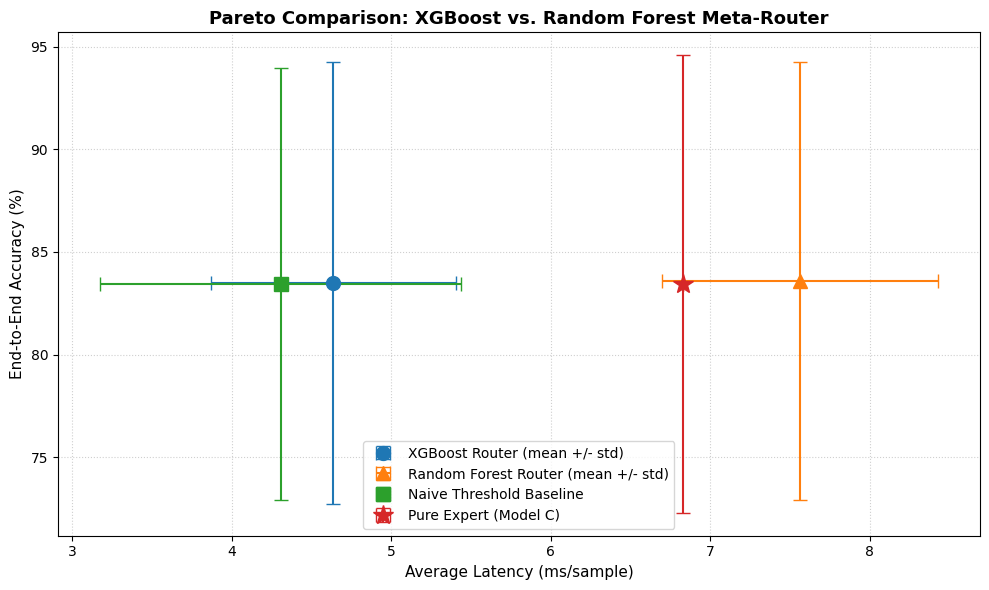

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(trial_df['xgb_latency'].mean(), trial_df['xgb_accuracy'].mean(),
            xerr=trial_df['xgb_latency'].std(), yerr=trial_df['xgb_accuracy'].std(),
            fmt='o', color='tab:blue', capsize=5, markersize=10, label='XGBoost Router (mean +/- std)')

ax.errorbar(trial_df['rf_latency'].mean(), trial_df['rf_accuracy'].mean(),
            xerr=trial_df['rf_latency'].std(), yerr=trial_df['rf_accuracy'].std(),
            fmt='^', color='tab:orange', capsize=5, markersize=10, label='Random Forest Router (mean +/- std)')

ax.errorbar(trial_df['naive_latency'].mean(), trial_df['naive_accuracy'].mean(),
            xerr=trial_df['naive_latency'].std(), yerr=trial_df['naive_accuracy'].std(),
            fmt='s', color='tab:green', capsize=5, markersize=10, label='Naive Threshold Baseline')

ax.errorbar(trial_df['expert_latency'].mean(), trial_df['expert_accuracy'].mean(),
            xerr=0, yerr=trial_df['expert_accuracy'].std(),
            fmt='*', color='tab:red', capsize=5, markersize=15, label='Pure Expert (Model C)')

ax.set_xlabel('Average Latency (ms/sample)', fontsize=11)
ax.set_ylabel('End-to-End Accuracy (%)', fontsize=11)
ax.set_title('Pareto Comparison: XGBoost vs. Random Forest Meta-Router', fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig('xgboost_vs_rf_pareto.png', dpi=150)
plt.show()
